# 05 — Aligned PPO (Learned Reward)

Train PPO using the learned reward model instead of the environment's reward. Evaluate on the *original* environment (no wrapper) to measure true performance, then compare against the baseline.

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import gymnasium as gym
from stable_baselines3 import PPO
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv
from pathlib import Path

from lunarlander.reward_model import RewardModel
from lunarlander.env_wrappers import LearnedRewardWrapper
from lunarlander.db_logger import ExperimentLogger

CHECKPOINT_DIR = Path('../checkpoints')
DB_PATH = Path('../experiments.db')
REWARD_MODEL_PATH = CHECKPOINT_DIR / 'reward_model.pt'
BASELINE_CKPT = CHECKPOINT_DIR / 'baseline_ppo.zip'

assert REWARD_MODEL_PATH.exists(), f'Run notebook 04 first! Missing {REWARD_MODEL_PATH}'
assert BASELINE_CKPT.exists(), f'Run notebook 01 first! Missing {BASELINE_CKPT}'

DEVICE = 'cpu'
print('Setup complete.')

Setup complete.


In [2]:
# Hyperparameters (same as baseline for fair comparison)
TOTAL_TIMESTEPS = 500_000
N_STEPS = 2048
BATCH_SIZE = 64
N_EPOCHS = 10
LEARNING_RATE = 3e-4
GAMMA = 0.999
GAE_LAMBDA = 0.98
ENT_COEF = 0.01
SEED = 42
N_EVAL_EPISODES = 50

hyperparams = {
    'total_timesteps': TOTAL_TIMESTEPS,
    'n_steps': N_STEPS,
    'batch_size': BATCH_SIZE,
    'n_epochs': N_EPOCHS,
    'learning_rate': LEARNING_RATE,
    'gamma': GAMMA,
    'gae_lambda': GAE_LAMBDA,
    'ent_coef': ENT_COEF,
    'seed': SEED,
    'reward': 'learned (Bradley-Terry MLP)',
}

In [3]:
# Load learned reward model
reward_model = RewardModel.load(REWARD_MODEL_PATH, device=DEVICE)
print(f'Reward model loaded. Feat dim: {reward_model.feat_dim}')

Reward model loaded from ../checkpoints/reward_model.pt
Reward model loaded. Feat dim: 12


In [ ]:
# Create wrapped environment (learned reward mixed with env reward during training)
def make_wrapped_env():
    base_env = gym.make('LunarLander-v3')
    wrapped = LearnedRewardWrapper(base_env, reward_model=reward_model, device=DEVICE, scale=0.5)
    return Monitor(wrapped)

train_env = DummyVecEnv([make_wrapped_env])
print('Wrapped training environment created. Reward = env_reward + 0.5 * learned_reward')

In [5]:
# Train aligned PPO
aligned_model = PPO(
    'MlpPolicy',
    train_env,
    n_steps=N_STEPS,
    batch_size=BATCH_SIZE,
    n_epochs=N_EPOCHS,
    learning_rate=LEARNING_RATE,
    gamma=GAMMA,
    gae_lambda=GAE_LAMBDA,
    ent_coef=ENT_COEF,
    verbose=1,
    seed=SEED,
)

print(f'Training aligned PPO for {TOTAL_TIMESTEPS:,} timesteps...')
aligned_model.learn(total_timesteps=TOTAL_TIMESTEPS, progress_bar=True)
print('Training complete!')

Using cuda device


Output()

/home/har5ha/Desktop/LunarLander/.venv/lib/python3.11/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


Training aligned PPO for 500,000 timesteps...


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 94.7     |
|    ep_rew_mean     | -46.8    |
| time/              |          |
|    fps             | 1274     |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 2048     |
---------------------------------


...

------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 217          |
|    ep_rew_mean          | 625          |
| time/                   |              |
|    fps                  | 976          |
|    iterations           | 242          |
|    time_elapsed         | 507          |
|    total_timesteps      | 495616       |
| train/                  |              |
|    approx_kl            | 0.0013174029 |
|    clip_fraction        | 0.00581      |
|    clip_range           | 0.2          |
|    entropy_loss         | -0.296       |
|    explained_variance   | 0.907        |
|    learning_rate        | 0.0003       |
|    loss                 | 9.79e+03     |
|    n_updates            | 2410         |
|    policy_gradient_loss | -0.00061     |
|    value_loss           | 2.01e+04     |
------------------------------------------


------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 218          |
|    ep_rew_mean          | 642          |
| time/                   |              |
|    fps                  | 976          |
|    iterations           | 243          |
|    time_elapsed         | 509          |
|    total_timesteps      | 497664       |
| train/                  |              |
|    approx_kl            | 0.0011873554 |
|    clip_fraction        | 0.002        |
|    clip_range           | 0.2          |
|    entropy_loss         | -0.229       |
|    explained_variance   | 0.874        |
|    learning_rate        | 0.0003       |
|    loss                 | 4.09e+03     |
|    n_updates            | 2420         |
|    policy_gradient_loss | -0.000848    |
|    value_loss           | 9.11e+03     |
------------------------------------------


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 218         |
|    ep_rew_mean          | 634         |
| time/                   |             |
|    fps                  | 976         |
|    iterations           | 244         |
|    time_elapsed         | 511         |
|    total_timesteps      | 499712      |
| train/                  |             |
|    approx_kl            | 0.001119192 |
|    clip_fraction        | 0.00552     |
|    clip_range           | 0.2         |
|    entropy_loss         | -0.284      |
|    explained_variance   | 0.892       |
|    learning_rate        | 0.0003      |
|    loss                 | 3.28e+03    |
|    n_updates            | 2430        |
|    policy_gradient_loss | -0.000587   |
|    value_loss           | 1.28e+04    |
-----------------------------------------


-------------------------------------------
| rollout/                |               |
|    ep_len_mean          | 224           |
|    ep_rew_mean          | 660           |
| time/                   |               |
|    fps                  | 976           |
|    iterations           | 245           |
|    time_elapsed         | 514           |
|    total_timesteps      | 501760        |
| train/                  |               |
|    approx_kl            | 0.00041149522 |
|    clip_fraction        | 0.00137       |
|    clip_range           | 0.2           |
|    entropy_loss         | -0.314        |
|    explained_variance   | 0.968         |
|    learning_rate        | 0.0003        |
|    loss                 | 1.45e+03      |
|    n_updates            | 2440          |
|    policy_gradient_loss | -0.000714     |
|    value_loss           | 4.02e+03      |
-------------------------------------------


Training complete!


In [6]:
# Evaluate on ORIGINAL (unwrapped) environment — true performance measure
def make_raw_env():
    return Monitor(gym.make('LunarLander-v3'))

raw_eval_env = DummyVecEnv([make_raw_env])

aligned_mean, aligned_std = evaluate_policy(
    aligned_model, raw_eval_env, n_eval_episodes=N_EVAL_EPISODES, deterministic=True
)
print(f'Aligned PPO — Mean reward (original env): {aligned_mean:.2f} +/- {aligned_std:.2f}')

Aligned PPO — Mean reward (original env): -1120.63 +/- 1045.65


In [7]:
# Compute success/crash rates for aligned agent
raw_env = gym.make('LunarLander-v3')
episode_rewards_aligned = []
landed_count = 0
crashed_count = 0
ep_lengths = []

for _ in range(N_EVAL_EPISODES):
    obs, _ = raw_env.reset()
    ep_reward = 0.0
    ep_len = 0
    done = False
    while not done:
        action, _ = aligned_model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = raw_env.step(action)
        ep_reward += reward
        ep_len += 1
        done = terminated or truncated
        if terminated:
            if reward == 100:
                landed_count += 1
            elif reward == -100:
                crashed_count += 1
    episode_rewards_aligned.append(ep_reward)
    ep_lengths.append(ep_len)

aligned_success_rate = landed_count / N_EVAL_EPISODES
aligned_crash_rate = crashed_count / N_EVAL_EPISODES
aligned_mean_ep_len = float(np.mean(ep_lengths))

print(f'Success rate (landed): {aligned_success_rate:.2%}')
print(f'Crash rate:            {aligned_crash_rate:.2%}')
print(f'Mean episode length:   {aligned_mean_ep_len:.1f} steps')
raw_env.close()

Success rate (landed): 0.00%
Crash rate:            100.00%
Mean episode length:   146.3 steps


In [8]:
# Save aligned checkpoint
aligned_ckpt_path = CHECKPOINT_DIR / 'aligned_ppo'
aligned_model.save(str(aligned_ckpt_path))
print(f'Checkpoint saved to {aligned_ckpt_path}.zip')

Checkpoint saved to ../checkpoints/aligned_ppo.zip


In [9]:
# Log to SQLite
logger = ExperimentLogger(DB_PATH)
row_id = logger.log(
    name='Aligned PPO — Learned Reward',
    exp_type='aligned_ppo',
    mean_reward=float(aligned_mean),
    std_reward=float(aligned_std),
    success_rate=aligned_success_rate,
    crash_rate=aligned_crash_rate,
    mean_ep_len=aligned_mean_ep_len,
    hyperparams=hyperparams,
    notes=f'PPO trained with Bradley-Terry learned reward. Evaluated on original env ({N_EVAL_EPISODES} eps).',
)
print(f'Logged to SQLite, row id={row_id}')

Logged to SQLite, row id=6


In [10]:
# Load baseline stats for comparison
baseline_rows = logger.fetch_by_type('baseline_ppo')
assert baseline_rows, 'No baseline_ppo rows found — run notebook 01 first!'
b = baseline_rows[0]  # most recent

print('\n=== Comparison: Baseline vs Aligned PPO ===')
print(f'{"Metric":<22} {"Baseline":>12} {"Aligned":>12}')
print('-' * 48)
print(f'{"Mean Reward":<22} {b["mean_reward"]:>12.1f} {aligned_mean:>12.1f}')
print(f'{"Std Reward":<22} {b["std_reward"]:>12.1f} {aligned_std:>12.1f}')
print(f'{"Success Rate":<22} {b["success_rate"]:>12.2%} {aligned_success_rate:>12.2%}')
print(f'{"Crash Rate":<22} {b["crash_rate"]:>12.2%} {aligned_crash_rate:>12.2%}')
print(f'{"Mean Ep Length":<22} {b["mean_ep_len"]:>12.1f} {aligned_mean_ep_len:>12.1f}')


=== Comparison: Baseline vs Aligned PPO ===
Metric                     Baseline      Aligned
------------------------------------------------
Mean Reward                   270.9      -1120.6
Std Reward                     20.9       1045.7
Success Rate                100.00%        0.00%
Crash Rate                    0.00%      100.00%
Mean Ep Length                272.2        146.3


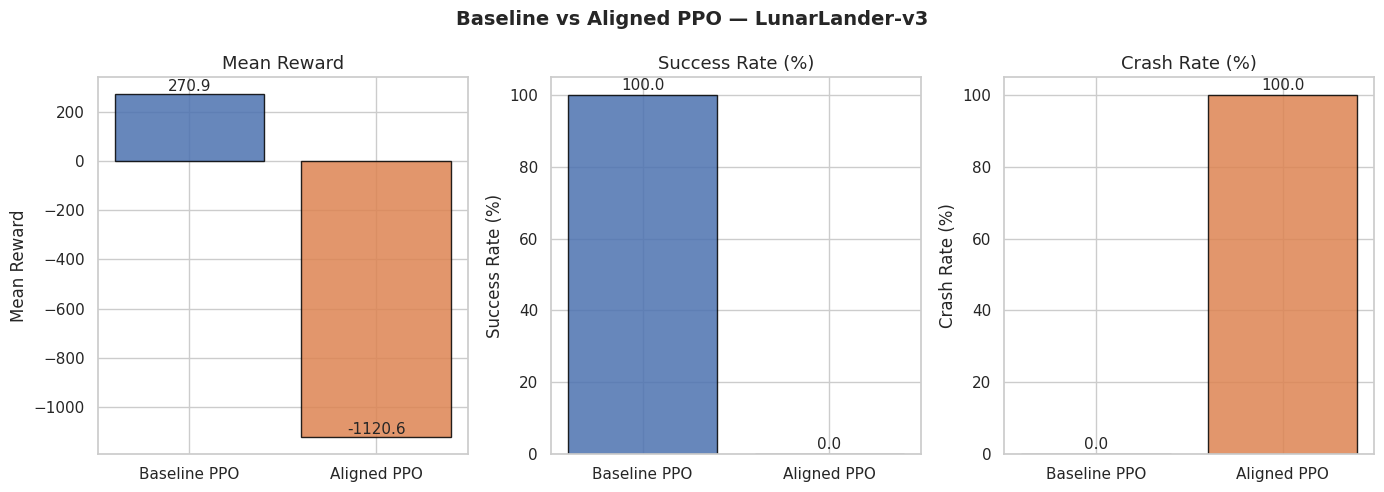

Comparison plot saved.


In [11]:
# Side-by-side comparison plots
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

metrics = ['Mean Reward', 'Success Rate (%)', 'Crash Rate (%)']
baseline_vals = [b['mean_reward'], b['success_rate'] * 100, b['crash_rate'] * 100]
aligned_vals  = [aligned_mean,     aligned_success_rate * 100, aligned_crash_rate * 100]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
colors = ['#4C72B0', '#DD8452']

for ax, metric, bval, aval in zip(axes, metrics, baseline_vals, aligned_vals):
    bars = ax.bar(['Baseline PPO', 'Aligned PPO'], [bval, aval], color=colors, edgecolor='black', alpha=0.85)
    ax.set_title(metric, fontsize=13)
    ax.set_ylabel(metric)
    for bar, val in zip(bars, [bval, aval]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}', ha='center', va='bottom', fontsize=11)

fig.suptitle('Baseline vs Aligned PPO — LunarLander-v3', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../checkpoints/comparison_plot.png', dpi=100)
plt.show()
print('Comparison plot saved.')

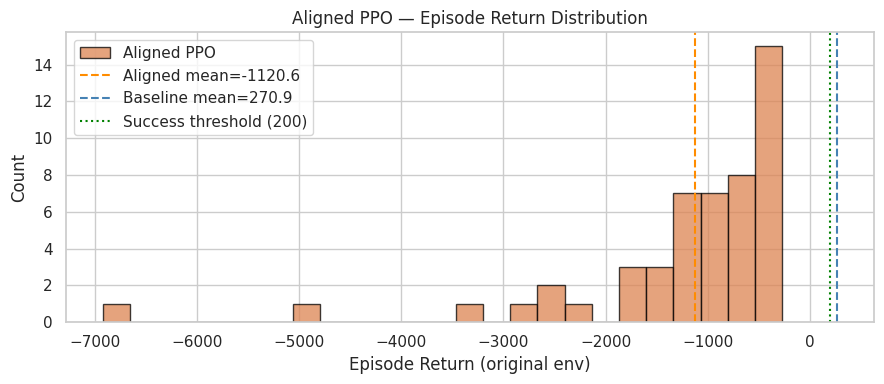

In [12]:
# Episode return distributions
# Need baseline episode rewards - load them if saved, else just show aligned
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(episode_rewards_aligned, bins=25, color='#DD8452', edgecolor='black', alpha=0.75, label='Aligned PPO')
ax.axvline(aligned_mean, color='darkorange', linestyle='--', label=f'Aligned mean={aligned_mean:.1f}')
ax.axvline(b['mean_reward'], color='steelblue', linestyle='--', label=f'Baseline mean={b["mean_reward"]:.1f}')
ax.axvline(200, color='green', linestyle=':', label='Success threshold (200)')
ax.set_xlabel('Episode Return (original env)')
ax.set_ylabel('Count')
ax.set_title('Aligned PPO — Episode Return Distribution')
ax.legend()
plt.tight_layout()
plt.savefig('../checkpoints/aligned_ppo_rewards.png', dpi=100)
plt.show()

In [ ]:
# Record both agents playing side-by-side and display as GIFs
import imageio
from IPython.display import Image as IPImage, display

def record_episode(model, label):
    env = gym.make('LunarLander-v3', render_mode='rgb_array')
    frames = []
    obs, _ = env.reset()
    done = False
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, _, terminated, truncated, _ = env.step(action)
        frames.append(env.render())
        done = terminated or truncated
    env.close()
    path = f'../checkpoints/{label}.gif'
    imageio.mimsave(path, frames, fps=30)
    print(f'{label}: {len(frames)} frames → {path}')
    return path

# Load baseline for comparison
baseline_model = PPO.load(str(BASELINE_CKPT))

print('=== Baseline PPO ===')
baseline_gif = record_episode(baseline_model, 'baseline_agent')
display(IPImage(baseline_gif))

print('\n=== Aligned PPO ===')
aligned_gif = record_episode(aligned_model, 'aligned_agent')
display(IPImage(aligned_gif))